In [14]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.19.0
GPU Available: []


In [15]:
# Create synthetic dataset - FIXED to avoid shape issues
def create_simple_segmentation_data(num_samples=500, img_size=64, num_classes=3):
    """
    Create simple synthetic segmentation data with proper class management
    """
    images = []
    masks = []
    
    for i in range(num_samples):
        # Create simple image
        img = np.random.randint(50, 200, (img_size, img_size, 3), dtype=np.uint8)
        
        # Create segmentation mask with exactly num_classes
        mask = np.zeros((img_size, img_size), dtype=np.uint8)
        
        # Class 1: Circle (make sure it's class 1, not exceeding num_classes-1)
        center = (np.random.randint(10, img_size-10), np.random.randint(10, img_size-10))
        radius = np.random.randint(5, 15)
        cv2.circle(mask, center, radius, 1, -1)
        cv2.circle(img, center, radius, (255, 100, 100), -1)
        
        # Class 2: Rectangle
        x1, y1 = np.random.randint(0, img_size//2), np.random.randint(0, img_size//2)
        x2, y2 = x1 + np.random.randint(10, 20), y1 + np.random.randint(10, 20)
        x2, y2 = min(x2, img_size-1), min(y2, img_size-1)
        cv2.rectangle(mask, (x1, y1), (x2, y2), 2, -1)
        cv2.rectangle(img, (x1, y1), (x2, y2), (100, 255, 100), -1)
        
        images.append(img)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

# Generate data with fixed parameters
NUM_CLASSES = 3  # Background (0), Circle (1), Rectangle (2)
IMG_SIZE = 64    # Smaller for faster training
NUM_SAMPLES = 500

print("Generating synthetic segmentation dataset...")
X, y = create_simple_segmentation_data(num_samples=NUM_SAMPLES, img_size=IMG_SIZE, num_classes=NUM_CLASSES)

# Normalize images
X = X.astype('float32') / 255.0

# Split data
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Unique values in masks: {np.unique(y_train)}")

# Convert masks to categorical - PROPERLY MANAGED
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"Categorical masks shape: {y_train_cat.shape}")
print(f"Expected model output shape: (batch_size, {IMG_SIZE}, {IMG_SIZE}, {NUM_CLASSES})")


Generating synthetic segmentation dataset...
Train set: (400, 64, 64, 3), (400, 64, 64)
Test set: (100, 64, 64, 3), (100, 64, 64)
Number of classes: 3
Unique values in masks: [0 1 2]
Categorical masks shape: (400, 64, 64, 3)
Expected model output shape: (batch_size, 64, 64, 3)


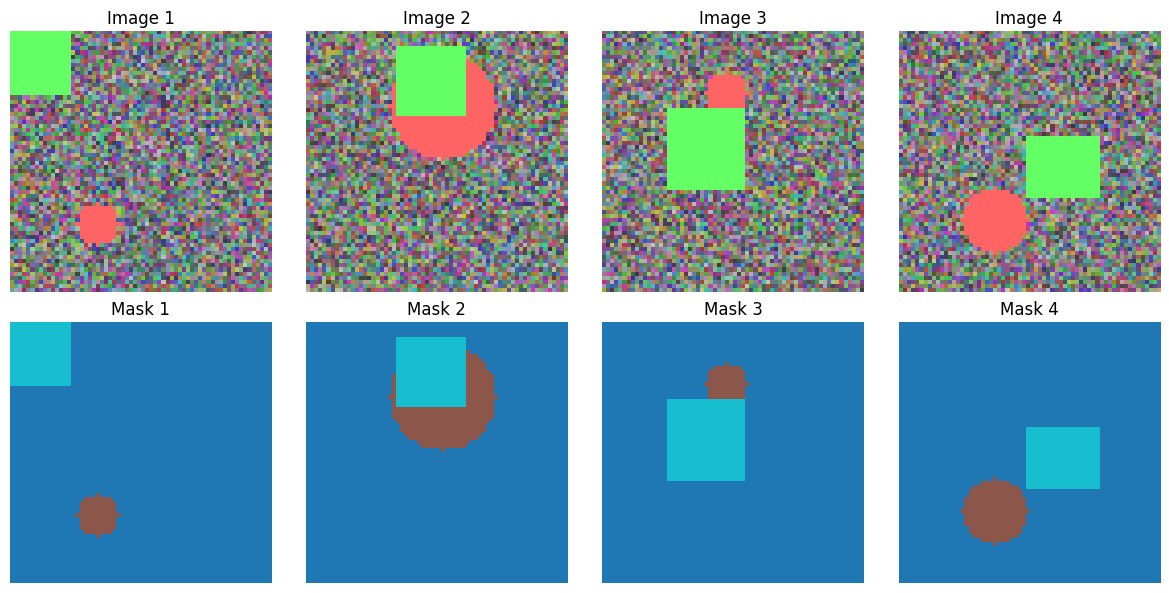

In [16]:
# Visualize samples to verify
def visualize_samples(images, masks, num_samples=4):
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))
    
    for i in range(num_samples):
        # Original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        
        # Segmentation mask
        axes[1, i].imshow(masks[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(X_train[:4], y_train[:4])


In [18]:
# Simple U-Net model - EASY VERSION
def build_simple_unet(input_shape, num_classes):
    """
    Build a simple U-Net model with proper shape handling
    """
    inputs = layers.Input(input_shape)
    
    # Encoder
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    
    # Bottom
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)
    
    # Decoder
    up4 = layers.UpSampling2D(size=(2, 2))(conv3)
    up4 = layers.Conv2D(64, 2, activation='relu', padding='same')(up4)
    merge4 = layers.Concatenate()([conv2, up4])
    conv4 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge4)
    conv4 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv4)
    
    up5 = layers.UpSampling2D(size=(2, 2))(conv4)
    up5 = layers.Conv2D(32, 2, activation='relu', padding='same')(up5)
    merge5 = layers.Concatenate()([conv1, up5])
    conv5 = layers.Conv2D(32, 3, activation='relu', padding='same')(merge5)
    conv5 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv5)
    
    # Output layer - ENSURE CORRECT NUMBER OF CLASSES
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(conv5)
    
    model = Model(inputs=inputs, outputs=outputs, name='Simple_UNet')
    return model

# Build U-Net model
input_shape = (IMG_SIZE, IMG_SIZE, 3)
unet_model = build_simple_unet(input_shape, NUM_CLASSES)

print(f"U-Net input shape: {input_shape}")
print(f"U-Net output classes: {NUM_CLASSES}")
unet_model.summary()


U-Net input shape: (64, 64, 3)
U-Net output classes: 3


Model: "Simple_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 64, 64,    │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 64, 64,    │      9,248 │ conv2d_106[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 32, 32,    │          0 │ conv2d_107[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 32, 32,    │     18,496 │ max_pooling2d_24… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 32, 32,    │     36,928 │ conv2d_108[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, 16, 16,    │          0 │ conv2d_109[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 16, 16,    │     73,856 │ max_pooling2d_25… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 16, 16,    │    147,584 │ conv2d_110[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_11    │ (None, 32, 32,    │          0 │ conv2d_111[0][0]  │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 32, 32,    │     32,832 │ up_sampling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ conv2d_109[0][0], │
│ (Concatenate)       │ 128)              │            │ conv2d_112[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 32, 32,    │     73,792 │ concatenate_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_114 (Conv2D) │ (None, 32, 32,    │     36,928 │ conv2d_113[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_12    │ (None, 64, 64,    │          0 │ conv2d_114[0][0]  │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_115 (Conv2D) │ (None, 64, 64,    │      8,224 │ up_sampling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_107[0][0]

 Total params: 466,595 (1.78 MB)

 Trainable params: 466,595 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Simple SegNet model - EASY VERSION
def build_simple_segnet(input_shape, num_classes):
    """
    Build a simple SegNet model
    """
    inputs = layers.Input(input_shape)
    
    # Encoder
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    
    # Decoder
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    
    # Output layer
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='Simple_SegNet')
    return model

# Build SegNet model
segnet_model = build_simple_segnet(input_shape, NUM_CLASSES)
print(f"SegNet model created with {segnet_model.count_params()} parameters")


SegNet model created with 416291 parameters


In [20]:
# Custom IoU metric
def iou_metric(y_true, y_pred):
    """IoU metric for segmentation"""
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    
    intersection = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
    union = tf.reduce_sum(tf.cast(y_true + y_pred, tf.float32)) - intersection
    
    return intersection / (union + 1e-8)

# Compile and train U-Net - FIXED
print("Training U-Net model...")
unet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', iou_metric]
)

# Verify shapes before training
print(f"Input shape: {X_train.shape}")
print(f"Target shape: {y_train_cat.shape}")
print(f"Model output shape: {unet_model.output_shape}")

# Train with fewer epochs for demo
unet_history = unet_model.fit(
    X_train, y_train_cat,
    batch_size=8,  # Smaller batch size
    epochs=10,     # Fewer epochs for quick demo
    validation_data=(X_test, y_test_cat),
    verbose=1
)

print("U-Net training completed!")


Training U-Net model...
Input shape: (400, 64, 64, 3)
Target shape: (400, 64, 64, 3)
Model output shape: (None, 64, 64, 3)
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 396ms/step - accuracy: 0.8905 - iou_metric: 0.1942 - loss: 0.4791 - val_accuracy: 0.9774 - val_iou_metric: 3.1445 - val_loss: 0.0594
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 391ms/step - accuracy: 0.9877 - iou_metric: 3.4338 - loss: 0.0335 - val_accuracy: 0.9914 - val_iou_metric: 3.9135 - val_loss: 0.0190
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.9939 - iou_metric: 3.9625 - loss: 0.0159 - val_accuracy: 0.9960 - val_iou_metric: 4.4750 - val_loss: 0.0113
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step - accuracy: 0.9958 - iou_metric: 4.0316 - loss: 0.0113 - val_accuracy: 0.9955 - val_iou_metric: 4.3820 - val_loss: 0.0109
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 386ms/step - accuracy: 0.9964 - iou_metric: 4.1720 - loss: 0.0093 - val_accuracy: 0.9972 - val_iou_metric: 4.5836 - val_loss: 0.0074
Ep

In [21]:
# Train SegNet model - EASY VERSION
print("Training SegNet model...")
segnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', iou_metric]
)

segnet_history = segnet_model.fit(
    X_train, y_train_cat,
    batch_size=8,
    epochs=10,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

print("SegNet training completed!")


Training SegNet model...
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 529ms/step - accuracy: 0.8046 - iou_metric: 0.0153 - loss: 0.5517 - val_accuracy: 0.9035 - val_iou_metric: 0.7619 - val_loss: 0.1757
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step - accuracy: 0.9210 - iou_metric: 1.3682 - loss: 0.1534 - val_accuracy: 0.9353 - val_iou_metric: 1.3096 - val_loss: 0.1074
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 305ms/step - accuracy: 0.9568 - iou_metric: 2.1971 - loss: 0.0829 - val_accuracy: 0.9908 - val_iou_metric: 3.9758 - val_loss: 0.0240
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.9913 - iou_metric: 3.9213 - loss: 0.0224 - val_accuracy: 0.9882 - val_iou_metric: 3.7883 - val_loss: 0.0301
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 289ms/step - accuracy: 0.9920 - iou_metric: 3.8655 - loss: 0.0199 - val_accuracy: 0.9950 - val_iou_metric: 4.5292 - val_loss: 0.0129
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.9948 - iou_metric: 4.1895 - loss:

U-Net - Loss: 0.0030, Accuracy: 0.9989, IoU: 4.4544
SegNet - Loss: 0.0095, Accuracy: 0.9962, IoU: 4.4172


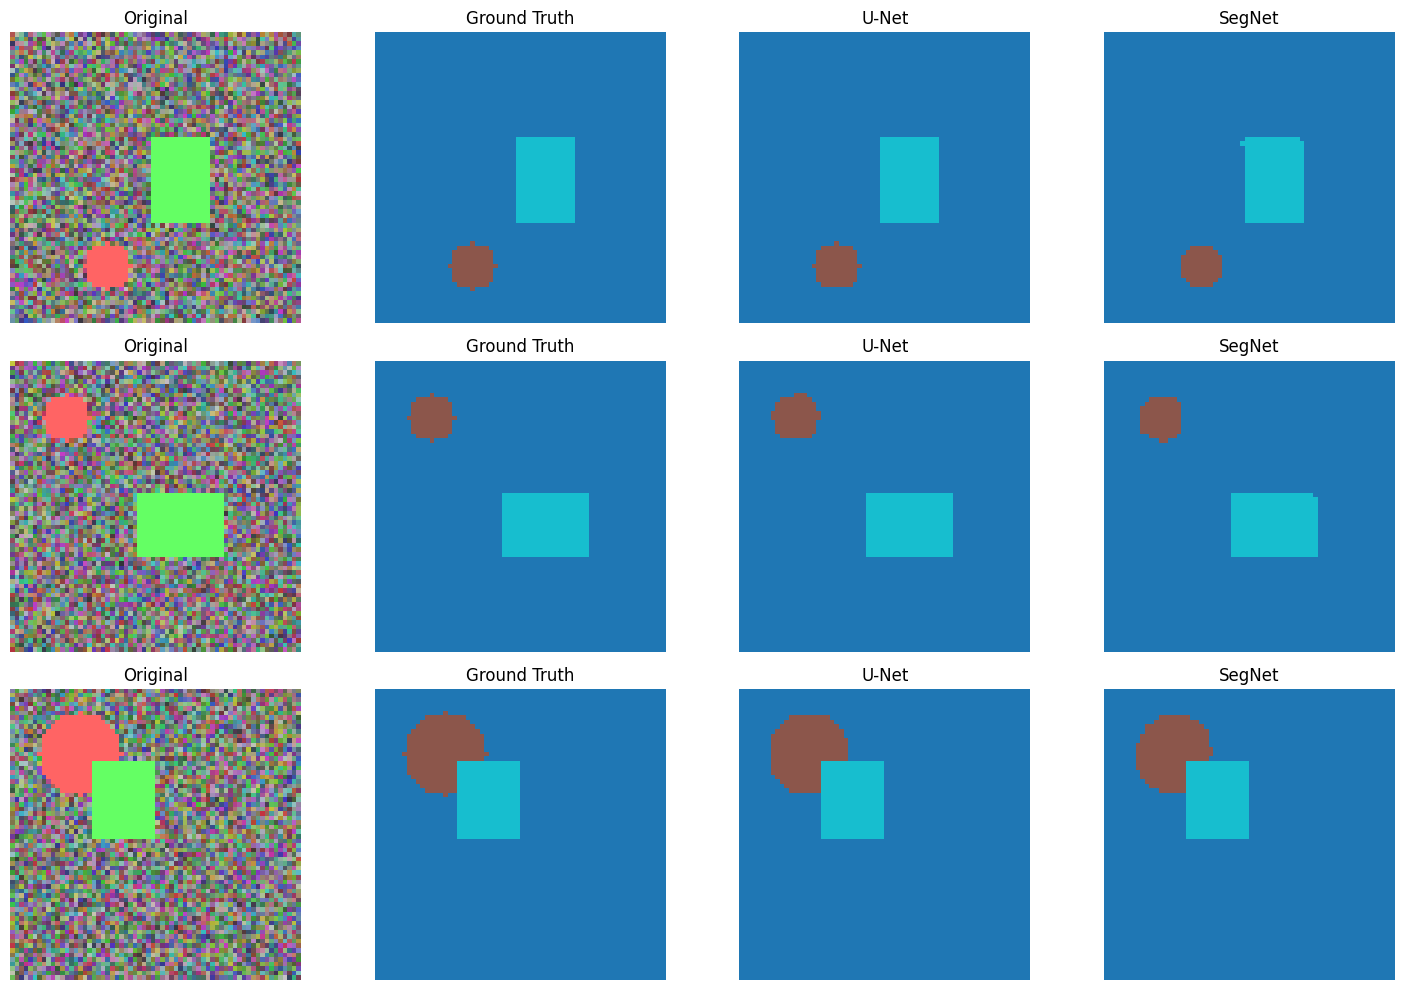

In [22]:
# Evaluate models
models = {'U-Net': unet_model, 'SegNet': segnet_model}
results = {}

for name, model in models.items():
    eval_results = model.evaluate(X_test, y_test_cat, verbose=0)
    results[name] = {
        'loss': eval_results[0],
        'accuracy': eval_results[1],
        'iou': eval_results[2]
    }
    print(f"{name} - Loss: {eval_results[0]:.4f}, Accuracy: {eval_results[1]:.4f}, IoU: {eval_results[2]:.4f}")

# Visualize predictions
def show_predictions(models, X_test, y_test, num_samples=3):
    fig, axes = plt.subplots(num_samples, len(models) + 2, figsize=(15, 10))
    
    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(y_test[i], cmap='tab10')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Model predictions
        for j, (name, model) in enumerate(models.items()):
            pred = model.predict(X_test[i:i+1], verbose=0)
            pred_mask = np.argmax(pred[0], axis=-1)
            axes[i, j + 2].imshow(pred_mask, cmap='tab10')
            axes[i, j + 2].set_title(f'{name}')
            axes[i, j + 2].axis('off')
    
    plt.tight_layout()
    plt.show()

show_predictions(models, X_test, y_test)
